# Customer Churn Prediction Platform

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the IBM Telco Customer Churn dataset, understand the available features, identify data quality issues, and gain business insights before building predictive models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns when viewing dataframes
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Overview

Before performing any analysis, it is important to understand the size, structure, and data types within the dataset.


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


## Column Information

Understanding each feature helps determine which variables may influence customer churn.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Missing Values

Missing data can negatively affect machine learning models. We check each feature before any preprocessing.


In [4]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

## Statistical Summary

Summary statistics provide an overview of the numerical variables in the dataset.


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Target Variable

The target variable is **Churn**, indicating whether a customer left the company.

Understanding the class distribution is important because machine learning models can become biased if one class heavily outweighs the other.


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

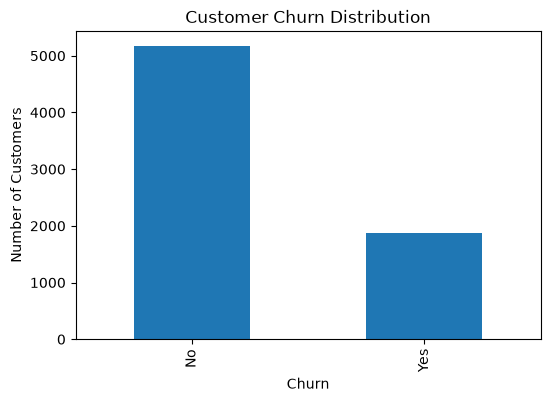

In [8]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight

The majority of customers did not churn.

This indicates that customer retention is generally good, but the company still loses a significant number of customers.

Predicting these customers before they leave could help the business reduce revenue loss through targeted retention strategies.


## Duplicate Records

Duplicate records can introduce bias into the analysis and negatively impact model performance. Before continuing, we verify whether duplicate customer records exist.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


## Unique Values

Understanding the number of unique values in each feature helps distinguish categorical variables from continuous variables and highlights potential identifier columns.

In [10]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,customerID,7043
1,gender,2
2,SeniorCitizen,2
3,Partner,2
4,Dependents,2
5,tenure,73
6,PhoneService,2
7,MultipleLines,3
8,InternetService,3
9,OnlineSecurity,3


## Data Types

The following table summarises the data type of each feature in the dataset.

In [11]:
dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

dtype_summary

,Column,Data Type
0,customerID,str
1,gender,str
2,SeniorCitizen,int64
3,Partner,str
4,Dependents,str
5,tenure,int64
6,PhoneService,str
7,MultipleLines,str
8,InternetService,str
9,OnlineSecurity,str
